# 🏠 RoomieMatch — Roommate Recommendation System
**Approach:** City-filtered Clustering (KMeans) + Cosine Similarity Ranking  
**Goal:** For any user, return their top-N most compatible roommate matches within the same city.  
**No target variable** — this is unsupervised learning. The "swipe right if..." columns act as compatibility weights.

---
## 📦 Section 1 — Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# Optional: UMAP for better 2D visualization (install if needed)
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP not installed. Using PCA for visualization. Run: pip install umap-learn")

# Optional: NLP on 'About Me'
try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    NLP_AVAILABLE = True
except ImportError:
    NLP_AVAILABLE = False

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
print('✅ All imports successful')

✅ All imports successful


---
## 📂 Section 2 — Load & Explore Data

In [2]:
df_raw = pd.read_csv('RoomieMatch.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Shape: (451, 24)


,Timestamp,About Me,University/CompaNew York,City,Budget,Property,Bedrooms,Bathrooms,laundry,Utilities,Furnished,Smoking preference,Noise preference,own pets,Comfortable Living with pets?,Cleanliness,Sleep schedule,Would you swipe right on someone if: [Different sleep schedule],Would you swipe right on someone if: [Slightly higher budget],Would you swipe right on someone if: [Has pets],Would you swipe right on someone if: [Smokes occasionally],Would you swipe right on someone if: [Is from a different university],Would you swipe right on someone if: [Frequently invites guests],Would you swipe right on someone if: [Prefers noisy environment]
0,2/20/2026 12:27:51,"I’m Ynez Dias, a graduate Computer Science student with ...",Stevens Institute of Technology,Jersey City,$1500–$2000,Apartment,2,2,Yes,Yes,Yes,I don’t smoke,Comfortable with noisy environment,No,No,5,Flexible,yes,No,No,No,yes,yes,No
1,2/20/2026 12:45:15,NaN,Northeastern university,New York,$2000–$3000,Apartment,2,2,Yes,Yes,Yes,I don’t smoke,Prefer quiet environment,No,No,5,Flexible,yes,yes,No,No,yes,No,No
2,2/20/2026 12:47:40,"I Swayam, I chill 👍",Stevens Institute of Technology,Jersey City,$500–$1000,"Apartment, House, Condo",4,2,Yes,Maybe,Yes,I smoke,Comfortable with noisy environment,No,Yes,5,Flexible,yes,yes,yes,yes,yes,yes,yes


In [11]:
df_raw.columns = df_raw.columns.str.strip()  # strips spaces first

RENAME_MAP = {
    'About Me': 'about_me',               # ← no trailing space
    'University/CompaNew York': 'university',
    'City': 'city',
    'Budget': 'budget',
    'Property': 'property_type',
    'Bedrooms': 'bedrooms',
    'Bathrooms': 'bathrooms',
    'laundry': 'laundry',
    'Utilities': 'utilities',
    'Furnished': 'furnished',
    'Smoking preference': 'smoking',       # ← no trailing space
    'Noise preference': 'noise',
    'own pets': 'has_pets',
    'Comfortable Living with pets?': 'pet_tolerance',
    'Cleanliness': 'cleanliness',
    'Sleep schedule': 'sleep_schedule',
    'Would you swipe right on someone if: [Different sleep schedule]': 'tol_diff_sleep',
    'Would you swipe right on someone if: [Slightly higher budget]': 'tol_higher_budget',
    'Would you swipe right on someone if: [Has pets]': 'tol_pets',
    'Would you swipe right on someone if: [Smokes occasionally]': 'tol_smoker',
    'Would you swipe right on someone if: [Is from a different university]': 'tol_diff_univ',
    'Would you swipe right on someone if: [Frequently invites guests]': 'tol_guests',
    'Would you swipe right on someone if: [Prefers noisy environment]': 'tol_noisy',
}

df = df_raw.rename(columns=RENAME_MAP).copy()
df['user_id'] = range(len(df))

print('Columns after rename:', df.columns.tolist())

Columns after rename: ['Timestamp', 'about_me', 'university', 'city', 'budget', 'property_type', 'bedrooms', 'bathrooms', 'laundry', 'utilities', 'furnished', 'smoking', 'noise', 'has_pets', 'pet_tolerance', 'cleanliness', 'sleep_schedule', 'tol_diff_sleep', 'tol_higher_budget', 'tol_pets', 'tol_smoker', 'tol_diff_univ', 'tol_guests', 'tol_noisy', 'user_id']


In [7]:
# Missing values
missing = df.isnull().sum()
missing[missing > 0]

About Me    9
laundry     2
dtype: int64

In [12]:
# Check what the most common value is
print(df['laundry'].value_counts())

# Fill with mode
df['laundry'] = df['laundry'].fillna(df['laundry'].mode()[0])

# Verify
print('Laundry nulls remaining:', df['laundry'].isnull().sum())

laundry
No     227
Yes    222
Name: count, dtype: int64
Laundry nulls remaining: 0


In [13]:
df['about_me'] = df['about_me'].fillna('No description provided')

print('About Me nulls remaining:', df['about_me'].isnull().sum())

About Me nulls remaining: 0


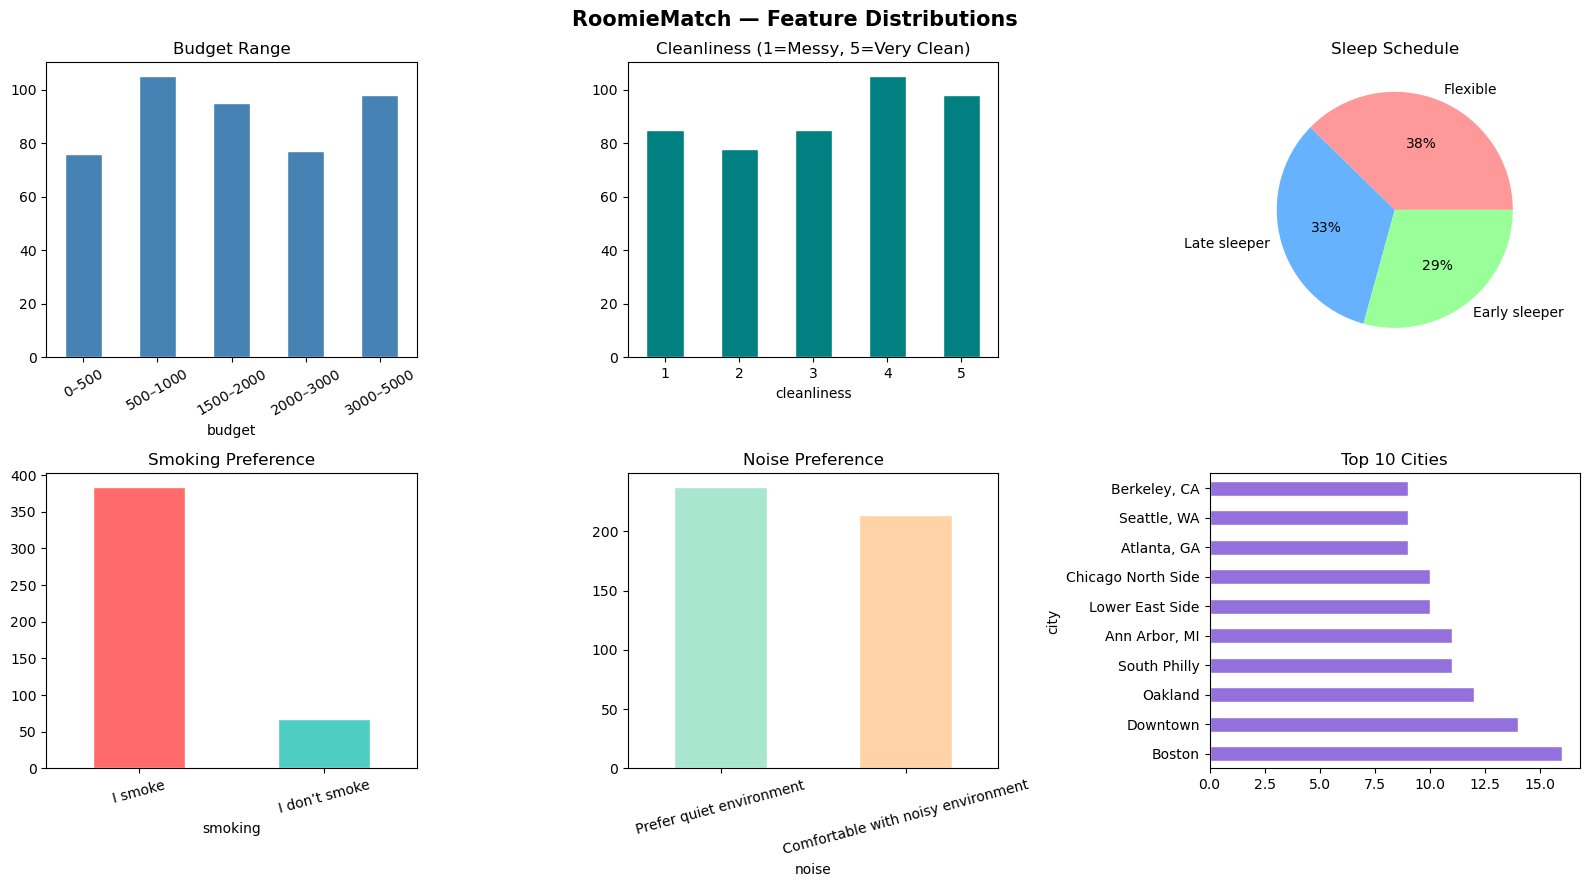

In [14]:
# EDA — Key distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('RoomieMatch — Feature Distributions', fontsize=15, fontweight='bold')

# Budget
budget_order = ['$0–$500', '$500–$1000', '$1500–$2000', '$2000–$3000', '$3000–$5000']
df['budget'].value_counts().reindex(budget_order).plot(kind='bar', ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Budget Range'); axes[0,0].tick_params(axis='x', rotation=30)

# Cleanliness
df['cleanliness'].value_counts().sort_index().plot(kind='bar', ax=axes[0,1], color='teal', edgecolor='white')
axes[0,1].set_title('Cleanliness (1=Messy, 5=Very Clean)'); axes[0,1].tick_params(axis='x', rotation=0)

# Sleep schedule
df['sleep_schedule'].value_counts().plot(kind='pie', ax=axes[0,2], autopct='%1.0f%%', colors=['#FF9999','#66B2FF','#99FF99'])
axes[0,2].set_title('Sleep Schedule'); axes[0,2].set_ylabel('')

# Smoking
df['smoking'].value_counts().plot(kind='bar', ax=axes[1,0], color=['#FF6B6B','#4ECDC4'], edgecolor='white')
axes[1,0].set_title('Smoking Preference'); axes[1,0].tick_params(axis='x', rotation=15)

# Noise
df['noise'].value_counts().plot(kind='bar', ax=axes[1,1], color=['#A8E6CF','#FFD3A5'], edgecolor='white')
axes[1,1].set_title('Noise Preference'); axes[1,1].tick_params(axis='x', rotation=15)

# Top cities
df['city'].value_counts().head(10).plot(kind='barh', ax=axes[1,2], color='mediumpurple', edgecolor='white')
axes[1,2].set_title('Top 10 Cities')

plt.tight_layout()
plt.show()

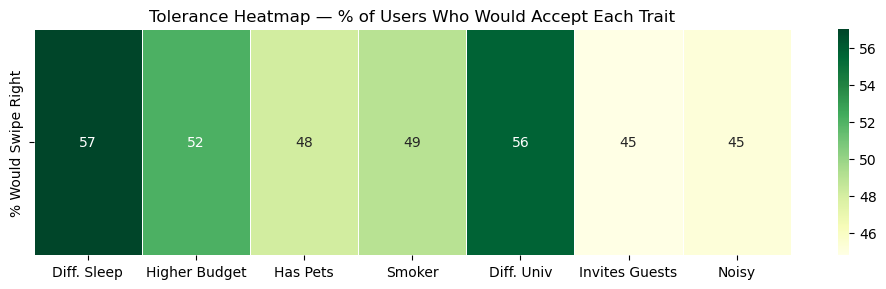

In [16]:
# Tolerance heatmap — how open are users to different traits?
tol_cols = ['tol_diff_sleep','tol_higher_budget','tol_pets','tol_smoker','tol_diff_univ','tol_guests','tol_noisy']
tol_labels = ['Diff. Sleep','Higher Budget','Has Pets','Smoker','Diff. Univ','Invites Guests','Noisy']

tol_pct = (df[tol_cols].apply(lambda col: col.str.lower().str.strip()) == 'yes').mean() * 100
tol_pct.index = tol_labels

plt.figure(figsize=(10, 3))
sns.heatmap(tol_pct.values.reshape(1, -1), annot=True, fmt='.0f', cmap='YlGn',
            xticklabels=tol_labels, yticklabels=['% Would Swipe Right'], linewidths=0.5)
plt.title('Tolerance Heatmap — % of Users Who Would Accept Each Trait', fontsize=12)
plt.tight_layout()
plt.show()

---
## 🔧 Section 3 — Data Cleaning & Feature Engineering

In [17]:
df_clean = df.copy()

# ── 3.1  City normalization (strip whitespace + title case) ──────────────────
df_clean['city'] = df_clean['city'].str.strip().str.title()

# ── 3.2  Budget → ordinal numeric ────────────────────────────────────────────
BUDGET_MAP = {'$0–$500': 1, '$500–$1000': 2, '$1500–$2000': 3, '$2000–$3000': 4, '$3000–$5000': 5}
df_clean['budget_num'] = df_clean['budget'].map(BUDGET_MAP)

# ── 3.3  Binary encode yes/no/maybe columns ───────────────────────────────────
YES_NO_MAP = {'yes': 1, 'no': 0, 'maybe': 0.5}

for col in ['laundry', 'has_pets']:
    df_clean[col + '_enc'] = df_clean[col].str.strip().str.lower().map({'yes': 1, 'no': 0})

for col in ['utilities', 'furnished', 'pet_tolerance']:
    df_clean[col + '_enc'] = df_clean[col].str.strip().str.lower().map(YES_NO_MAP)

# ── 3.4  Smoking → binary ─────────────────────────────────────────────────────
df_clean['smoking_enc'] = (df_clean['smoking'].str.strip().str.lower() == 'i smoke').astype(int)

# ── 3.5  Noise → binary ───────────────────────────────────────────────────────
df_clean['noise_enc'] = (df_clean['noise'].str.strip().str.lower() == 'comfortable with noisy environment').astype(int)

# ── 3.6  Sleep schedule → ordinal ─────────────────────────────────────────────
SLEEP_MAP = {'Early sleeper': 0, 'Flexible': 1, 'Late sleeper': 2}
df_clean['sleep_enc'] = df_clean['sleep_schedule'].str.strip().map(SLEEP_MAP)

# ── 3.7  Property type — multi-hot encoding ───────────────────────────────────
df_clean['wants_apartment'] = df_clean['property_type'].str.contains('Apartment', case=False, na=False).astype(int)
df_clean['wants_house']     = df_clean['property_type'].str.contains('House',     case=False, na=False).astype(int)
df_clean['wants_condo']     = df_clean['property_type'].str.contains('Condo',     case=False, na=False).astype(int)

# ── 3.8  Bedrooms & Bathrooms — clip outliers ──────────────────────────────────
df_clean['bedrooms']  = df_clean['bedrooms'].clip(1, 6)
df_clean['bathrooms'] = df_clean['bathrooms'].clip(1, 6)

# ── 3.9  Tolerance columns → binary, then sum into tolerance_score ────────────
tol_cols = ['tol_diff_sleep','tol_higher_budget','tol_pets','tol_smoker','tol_diff_univ','tol_guests','tol_noisy']
for col in tol_cols:
    df_clean[col + '_enc'] = (df_clean[col].str.strip().str.lower() == 'yes').astype(int)

tol_enc_cols = [c + '_enc' for c in tol_cols]
df_clean['tolerance_score'] = df_clean[tol_enc_cols].sum(axis=1)  # 0–7, higher = more flexible

# ── 3.10  Fill remaining nulls with median/mode ───────────────────────────────
for col in ['laundry_enc', 'has_pets_enc', 'sleep_enc', 'budget_num']:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

print('✅ Cleaning done')
df_clean[['city','budget_num','smoking_enc','noise_enc','sleep_enc','cleanliness','tolerance_score']].head(5)

✅ Cleaning done


,city,budget_num,smoking_enc,noise_enc,sleep_enc,cleanliness,tolerance_score
0,Jersey City,3,0,1,1,5,3
1,New York,4,0,0,1,5,3
2,Jersey City,2,1,1,1,5,7
3,Brooklyn,2,0,0,0,4,2
4,New Jersey,5,0,0,0,5,4


In [18]:
# ── 3.11  (Optional) NLP on 'About Me' using TF-IDF ─────────────────────────
if NLP_AVAILABLE:
    about_filled = df_clean['about_me'].fillna('no description')
    tfidf = TfidfVectorizer(max_features=20, stop_words='english', min_df=2)
    tfidf_matrix = tfidf.fit_transform(about_filled).toarray()
    tfidf_df = pd.DataFrame(tfidf_matrix, columns=['nlp_' + w for w in tfidf.get_feature_names_out()])
    df_clean = pd.concat([df_clean.reset_index(drop=True), tfidf_df], axis=1)
    NLP_FEATURES = tfidf_df.columns.tolist()
    print(f'✅ TF-IDF features added: {NLP_FEATURES[:5]} ...')
else:
    NLP_FEATURES = []
    print('Skipping NLP features.')

✅ TF-IDF features added: ['nlp_clean', 'nlp_enjoy', 'nlp_friendly', 'nlp_fun', 'nlp_hey'] ...


---
## 🤖 Section 4 — Clustering with KMeans

In [19]:
# Define the feature set used for clustering
# City is NOT included here — it is used as a hard pre-filter before recommending

CLUSTER_FEATURES = [
    'budget_num',
    'cleanliness',
    'sleep_enc',
    'smoking_enc',
    'noise_enc',
    'has_pets_enc',
    'pet_tolerance_enc',
    'laundry_enc',
    'utilities_enc',
    'furnished_enc',
    'bedrooms',
    'bathrooms',
    'wants_apartment',
    'wants_house',
    'wants_condo',
    'tolerance_score',
] + tol_enc_cols + NLP_FEATURES

X = df_clean[CLUSTER_FEATURES].fillna(0).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrix shape: {X_scaled.shape}')
print(f'Features used ({len(CLUSTER_FEATURES)}):', CLUSTER_FEATURES)

Feature matrix shape: (451, 43)
Features used (43): ['budget_num', 'cleanliness', 'sleep_enc', 'smoking_enc', 'noise_enc', 'has_pets_enc', 'pet_tolerance_enc', 'laundry_enc', 'utilities_enc', 'furnished_enc', 'bedrooms', 'bathrooms', 'wants_apartment', 'wants_house', 'wants_condo', 'tolerance_score', 'tol_diff_sleep_enc', 'tol_higher_budget_enc', 'tol_pets_enc', 'tol_smoker_enc', 'tol_diff_univ_enc', 'tol_guests_enc', 'tol_noisy_enc', 'nlp_clean', 'nlp_enjoy', 'nlp_friendly', 'nlp_fun', 'nlp_hey', 'nlp_hi', 'nlp_like', 'nlp_live', 'nlp_looking', 'nlp_love', 'nlp_organized', 'nlp_quiet', 'nlp_respectful', 'nlp_roommate', 'nlp_space', 'nlp_student', 'nlp_things', 'nlp_tidy', 'nlp_university', 'nlp_weekend']


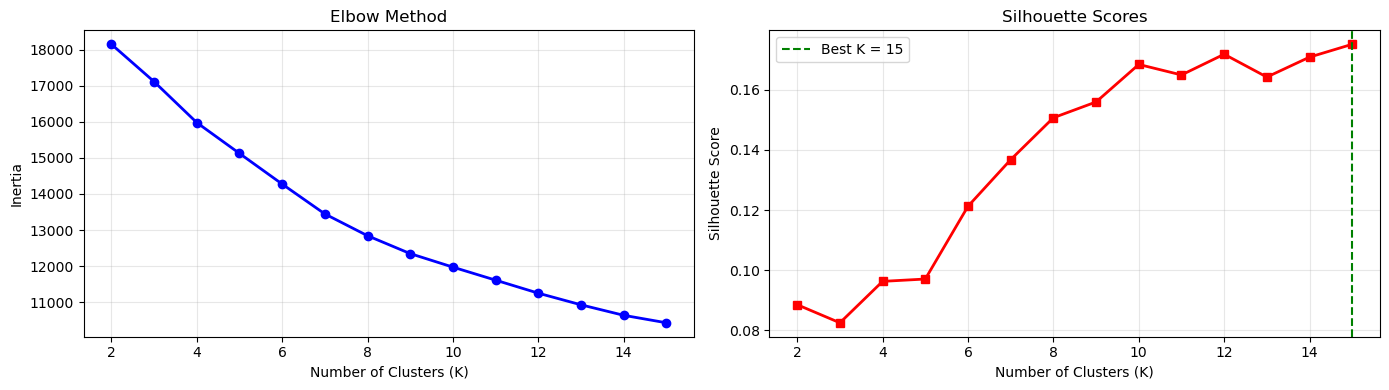

🏆 Suggested optimal K (best silhouette): 15


In [20]:
# Elbow method + Silhouette scores to find optimal K
inertias = []
silhouettes = []
K_RANGE = range(2, 16)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=300, random_state=42))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(list(K_RANGE), inertias, 'bo-', linewidth=2)
ax1.set_xlabel('Number of Clusters (K)'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method'); ax1.grid(alpha=0.3)

ax2.plot(list(K_RANGE), silhouettes, 'rs-', linewidth=2)
ax2.set_xlabel('Number of Clusters (K)'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Scores'); ax2.grid(alpha=0.3)

best_k = list(K_RANGE)[np.argmax(silhouettes)]
ax2.axvline(x=best_k, color='green', linestyle='--', label=f'Best K = {best_k}')
ax2.legend()

plt.tight_layout()
plt.show()
print(f'🏆 Suggested optimal K (best silhouette): {best_k}')

In [21]:
# ── Fit final KMeans with chosen K ─────────────────────────────────────────────
# You can override this manually if you prefer a different K
OPTIMAL_K = best_k   # or set manually, e.g. OPTIMAL_K = 7

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

print(f'✅ KMeans fitted with K={OPTIMAL_K}')
print('\nUsers per cluster:')
print(df_clean['cluster'].value_counts().sort_index())

✅ KMeans fitted with K=15

Users per cluster:
cluster
0     25
1     46
2     15
3     51
4     29
5     49
6     29
7     20
8     28
9     23
10    17
11    24
12    22
13    22
14    51
Name: count, dtype: int64


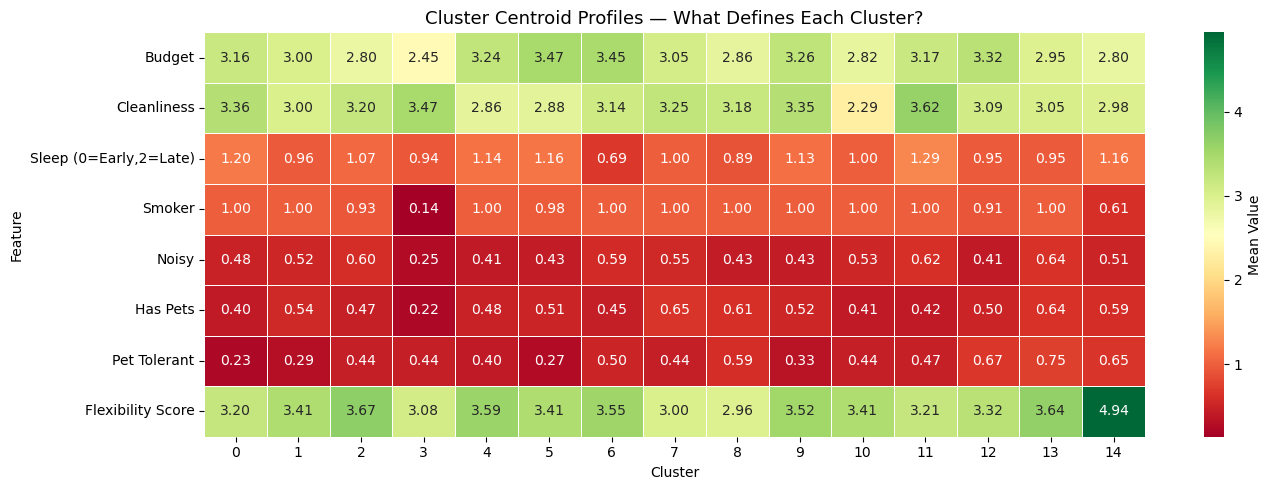

In [22]:
# Cluster centroid profiles — what makes each cluster unique?
profile_cols = ['budget_num','cleanliness','sleep_enc','smoking_enc','noise_enc',
                'has_pets_enc','pet_tolerance_enc','tolerance_score']
profile_labels = ['Budget','Cleanliness','Sleep (0=Early,2=Late)','Smoker',
                  'Noisy','Has Pets','Pet Tolerant','Flexibility Score']

centroids = df_clean.groupby('cluster')[profile_cols].mean()
centroids.columns = profile_labels

plt.figure(figsize=(14, 5))
sns.heatmap(centroids.T, annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.5,
            cbar_kws={'label': 'Mean Value'})
plt.title('Cluster Centroid Profiles — What Defines Each Cluster?', fontsize=13)
plt.ylabel('Feature'); plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

---
## 📊 Section 5 — 2D Cluster Visualization (PCA / UMAP)

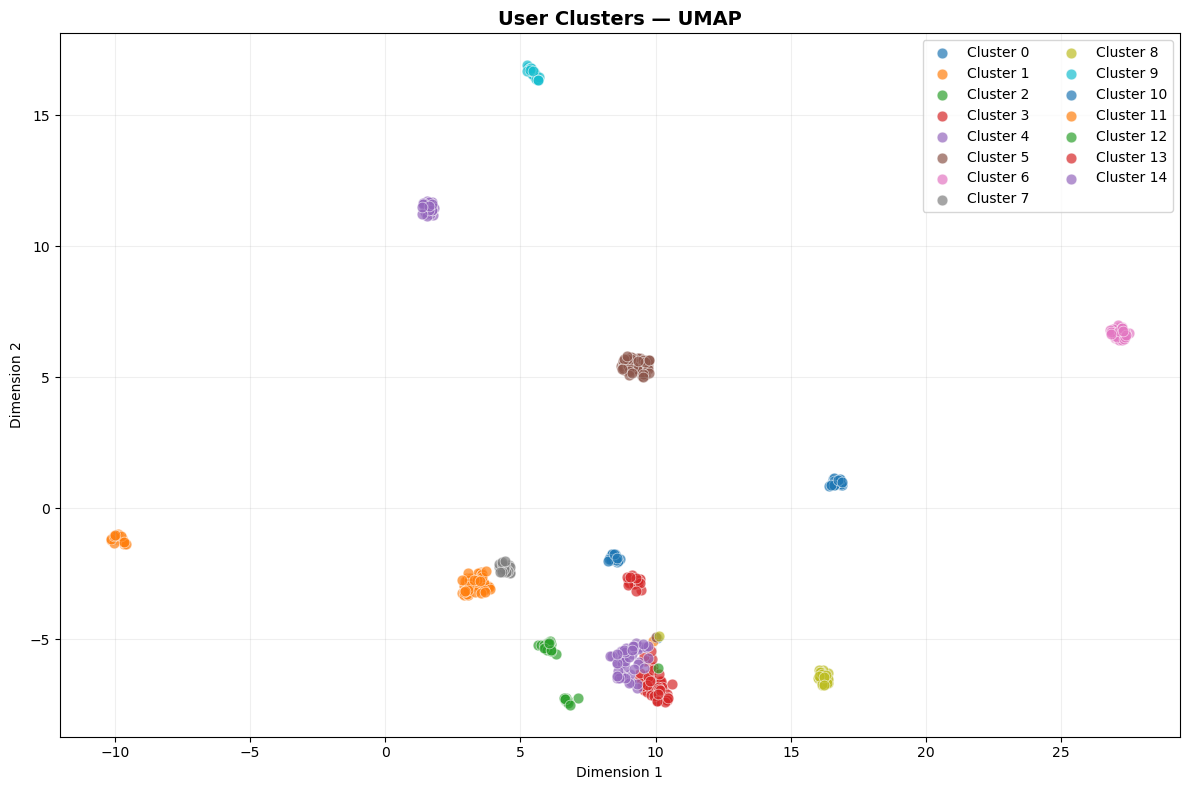

In [23]:
if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    X_2d = reducer.fit_transform(X_scaled)
    method = 'UMAP'
else:
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X_scaled)
    explained = pca.explained_variance_ratio_.sum() * 100
    method = f'PCA ({explained:.1f}% variance)'

df_clean['x_2d'] = X_2d[:, 0]
df_clean['y_2d'] = X_2d[:, 1]

plt.figure(figsize=(12, 8))
palette = plt.cm.tab10.colors
for cluster_id in sorted(df_clean['cluster'].unique()):
    mask = df_clean['cluster'] == cluster_id
    plt.scatter(df_clean.loc[mask, 'x_2d'], df_clean.loc[mask, 'y_2d'],
                color=palette[cluster_id % 10], label=f'Cluster {cluster_id}',
                alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

plt.title(f'User Clusters — {method}', fontsize=14, fontweight='bold')
plt.xlabel('Dimension 1'); plt.ylabel('Dimension 2')
plt.legend(loc='upper right', ncol=2)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

---
## 🎯 Section 6 — Recommendation Engine

> **Logic:** For a given user →  
> 1. Hard filter: keep only users in the same city  
> 2. Soft filter: prefer users in the same cluster  
> 3. Rank remaining users by cosine similarity on feature vectors  
> 4. Return top-N with a match % score

In [29]:
# Store the scaled feature matrix alongside user IDs for fast lookup
feature_matrix = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES)
feature_matrix['user_id'] = df_clean['user_id'].values
feature_matrix['city']    = df_clean['city'].values
feature_matrix['cluster'] = df_clean['cluster'].values

def get_recommendations(
    user_id: int,
    top_n: int = 10,
    same_cluster_only: bool = False,
    df_profiles = df_clean,
    feat_matrix = feature_matrix
) -> pd.DataFrame:
    """
    Returns top-N recommended roommates for a given user_id.

    Steps:
      1. Hard filter by city (same city only)
      2. Optional: filter by same cluster
      3. Rank by cosine similarity on feature vectors
      4. Return profiles + match_pct
    """
    if user_id not in df_profiles['user_id'].values:
        raise ValueError(f'user_id {user_id} not found.')

    user_row   = df_profiles[df_profiles['user_id'] == user_id].iloc[0]
    user_city  = user_row['city']
    user_cluster = user_row['cluster']

    # ── Step 1: city filter ────────────────────────────────────────────────────
    city_pool = feat_matrix[
        (feat_matrix['city'] == user_city) &
        (feat_matrix['user_id'] != user_id)
    ].copy()

    if city_pool.empty:
        return pd.DataFrame(columns=['user_id', 'match_pct'])

    # ── Step 2 (optional): cluster filter ─────────────────────────────────────
    if same_cluster_only:
        cluster_pool = city_pool[city_pool['cluster'] == user_cluster]
        # Fall back to city pool if cluster is too small
        city_pool = cluster_pool if len(cluster_pool) >= top_n else city_pool

    # ── Step 3: cosine similarity ──────────────────────────────────────────────
    user_vec    = feat_matrix.loc[
        feat_matrix['user_id'] == user_id, CLUSTER_FEATURES
    ].values
    pool_vecs   = city_pool[CLUSTER_FEATURES].values
    pool_ids    = city_pool['user_id'].values
    pool_clusters = city_pool['cluster'].values

    similarities = cosine_similarity(user_vec, pool_vecs)[0]
    match_pct    = (similarities * 100).round(1)

    # ── Step 4: build result DataFrame ─────────────────────────────────────────
    results = pd.DataFrame({
        'user_id'   : pool_ids,
        'cluster'   : pool_clusters,
        'match_pct' : match_pct
    }).sort_values('match_pct', ascending=False).head(top_n)

    # Merge with profile info
    profile_cols_show = ['user_id','about_me','city','budget','smoking',
                         'noise','sleep_schedule','cleanliness','cluster']
    merged = results.merge(
        df_profiles[profile_cols_show], on=['user_id','cluster'], how='left'
    )
    merged = merged[['match_pct','user_id','cluster','about_me',
                     'city','budget','smoking','noise','sleep_schedule','cleanliness']]
    return merged.reset_index(drop=True)

print('✅ Recommendation function defined')

✅ Recommendation function defined


In [30]:
# ── Demo: Get recommendations for user_id = 0 ────────────────────────────────
DEMO_USER = 0

user_profile = df_clean[df_clean['user_id'] == DEMO_USER][[
    'about_me','city','budget','smoking','noise','sleep_schedule','cleanliness','cluster'
]]

print('=== QUERY USER PROFILE ===')
print(user_profile.to_string(index=False))
print()

recs = get_recommendations(DEMO_USER, top_n=10)
print('=== TOP 10 RECOMMENDATIONS (same city) ===')
recs

=== QUERY USER PROFILE ===
                                                                                                                                                                                                                                          about_me        city      budget       smoking                              noise sleep_schedule  cleanliness  cluster
I’m Ynez Dias, a graduate Computer Science student with a strong interest in building scalable, user-centric applications. I enjoy combining problem-solving, software engineering, and data-driven approaches to create impactful tech solutions. Jersey City $1500–$2000 I don’t smoke Comfortable with noisy environment       Flexible            5        3

=== TOP 10 RECOMMENDATIONS (same city) ===


,match_pct,user_id,cluster,about_me,city,budget,smoking,noise,sleep_schedule,cleanliness
0,35.7,64,3,No description provided,Jersey City,$0–$500,I don’t smoke,Prefer quiet environment,Flexible,5
1,33.0,22,3,Hi! I’m Yuktha. I’m a grad student in Engineering Manag...,Jersey City,$0–$500,I don’t smoke,Comfortable with noisy environment,Late sleeper,5
2,24.1,431,5,"Hi! I'm Khalid Ahmed, a student at Stevens Institute of ...",Jersey City,$3000–$5000,I smoke,Prefer quiet environment,Late sleeper,5
3,20.8,71,14,Yash Tanaji Bhosale,Jersey City,$1500–$2000,I don’t smoke,Prefer quiet environment,Late sleeper,5
4,14.3,440,0,I'm Riya Bhatia from Stevens Institute of Technology. I ...,Jersey City,$3000–$5000,I smoke,Prefer quiet environment,Early sleeper,2
5,9.5,79,14,Chinmay Shinde,Jersey City,$500–$1000,I don’t smoke,Comfortable with noisy environment,Flexible,3
6,8.6,147,6,Hey! Layla Malik from Stevens Institute of Technology. I...,Jersey City,$3000–$5000,I smoke,Prefer quiet environment,Flexible,5
7,1.3,2,14,"I Swayam, I chill 👍",Jersey City,$500–$1000,I smoke,Comfortable with noisy environment,Flexible,5
8,-13.7,205,1,"Hey, I'm John Miller. Freshman at Stevens Institute of T...",Jersey City,$1500–$2000,I smoke,Prefer quiet environment,Flexible,5


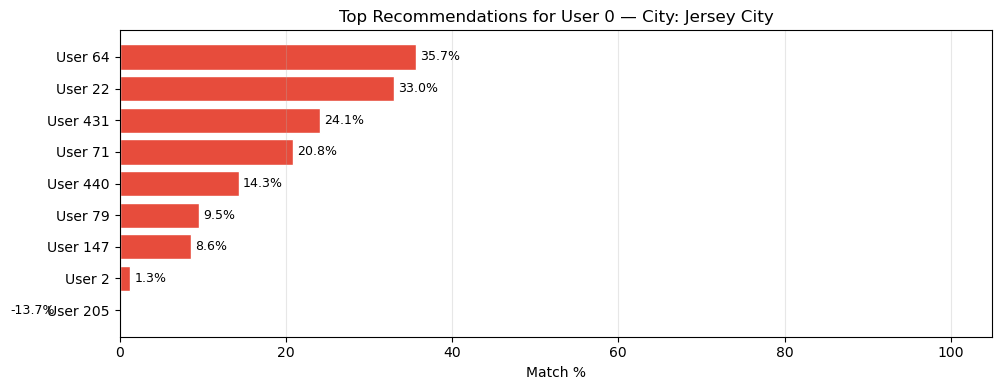

In [31]:
# ── Visualize match scores for the demo user ──────────────────────────────────
if not recs.empty:
    plt.figure(figsize=(10, 4))
    colors = ['#2ECC71' if x >= 80 else '#F39C12' if x >= 60 else '#E74C3C'
              for x in recs['match_pct']]
    bars = plt.barh(range(len(recs)), recs['match_pct'], color=colors, edgecolor='white')
    plt.yticks(range(len(recs)), [f'User {uid}' for uid in recs['user_id']])
    plt.xlabel('Match %')
    plt.title(f'Top Recommendations for User {DEMO_USER} — City: {df_clean.loc[DEMO_USER, "city"]}')
    plt.xlim(0, 105)
    for bar, val in zip(bars, recs['match_pct']):
        plt.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=9)
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [32]:
# ── Try another user — use same_cluster_only=True for stricter matching ───────
ANOTHER_USER = 5
recs2 = get_recommendations(ANOTHER_USER, top_n=10, same_cluster_only=True)
print(f'Recommendations for User {ANOTHER_USER} (cluster-filtered):')
recs2

Recommendations for User 5 (cluster-filtered):


,match_pct,user_id,cluster,about_me,city,budget,smoking,noise,sleep_schedule,cleanliness
0,70.5,4,3,Jason Dsilva,New Jersey,$3000–$5000,I don’t smoke,Prefer quiet environment,Early sleeper,5
1,59.2,111,3,C,New Jersey,$500–$1000,I don’t smoke,Prefer quiet environment,Flexible,4
2,43.4,52,3,Bhushan,New Jersey,$3000–$5000,I don’t smoke,Prefer quiet environment,Late sleeper,5
3,41.2,99,3,Isaiah Gonsalves,New Jersey,$1500–$2000,I smoke,Prefer quiet environment,Flexible,1
4,39.9,84,3,"Hi Julie Dsilva here, I don’t bring the party home, but ...",New Jersey,$500–$1000,I don’t smoke,Prefer quiet environment,Flexible,2
5,31.9,73,3,"Hi Mabel Dsilva here, I don’t bring the party home, but ...",New Jersey,$500–$1000,I don’t smoke,Prefer quiet environment,Late sleeper,1
6,21.9,106,14,Prem,New Jersey,$1500–$2000,I don’t smoke,Prefer quiet environment,Late sleeper,3
7,17.8,72,3,"About me: Hi I am Swetlana Dias, I’m a very reliable and...",New Jersey,$500–$1000,I don’t smoke,Prefer quiet environment,Flexible,1
8,-16.2,43,14,"Chloe, Deeply introverted but very friendly once the ice...",New Jersey,$0–$500,I don’t smoke,Comfortable with noisy environment,Late sleeper,2


---
## 📤 Section 7 — Export All Recommendations to CSV

In [ ]:
all_recs = []

for uid in df_clean['user_id'].values:
    try:
        user_recs = get_recommendations(uid, top_n=10)
        if not user_recs.empty:
            user_recs.insert(0, 'query_user_id', uid)
            all_recs.append(user_recs)
    except Exception:
        pass  # skip users with no city matches

recommendations_df = pd.concat(all_recs, ignore_index=True)
recommendations_df.to_csv('roomie_recommendations.csv', index=False)

print(f'✅ Exported {len(recommendations_df)} recommendation rows to roomie_recommendations.csv')
recommendations_df.head()

---
## 📈 Section 8 — Evaluation

In [ ]:
# ── 8.1  Overall silhouette score ────────────────────────────────────────────
final_sil = silhouette_score(X_scaled, df_clean['cluster'])
print(f'🏆 Final Silhouette Score (K={OPTIMAL_K}): {final_sil:.4f}')
print('   (>0.2 = reasonable, >0.5 = strong separation)')

# ── 8.2  Per-cluster silhouette ──────────────────────────────────────────────
from sklearn.metrics import silhouette_samples
sample_sil = silhouette_samples(X_scaled, df_clean['cluster'])
df_clean['silhouette'] = sample_sil

cluster_eval = df_clean.groupby('cluster').agg(
    size=('user_id', 'count'),
    mean_silhouette=('silhouette', 'mean'),
    mean_match_pct=('user_id', lambda x: recommendations_df[
        recommendations_df['query_user_id'].isin(x)]['match_pct'].mean()
    )
).round(3)

print('\nPer-cluster evaluation:')
cluster_eval

In [ ]:
# ── 8.3  Sanity check — show 3 sample user → recommendation pairs ────────────
SAMPLE_USERS = [0, 10, 30]
show_cols = ['about_me','city','budget','smoking','noise','sleep_schedule','cleanliness']

for uid in SAMPLE_USERS:
    q = df_clean[df_clean['user_id'] == uid][show_cols].iloc[0]
    top_match_id = get_recommendations(uid, top_n=1).iloc[0]['user_id']
    r = df_clean[df_clean['user_id'] == int(top_match_id)][show_cols].iloc[0]
    match_score = get_recommendations(uid, top_n=1).iloc[0]['match_pct']

    print(f'\n{'='*60}')
    print(f'🔍 QUERY  User {uid}   |   ✅ TOP MATCH  User {int(top_match_id)}   ({match_score}% match)')
    print(f'{'='*60}')
    comparison = pd.DataFrame({'Query': q.values, 'Top Match': r.values}, index=show_cols)
    print(comparison.to_string())

In [ ]:
# ── 8.4  Match score distribution across all recommendations ─────────────────
plt.figure(figsize=(10, 4))
plt.hist(recommendations_df['match_pct'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(recommendations_df['match_pct'].mean(), color='red', linestyle='--',
            label=f'Mean: {recommendations_df["match_pct"].mean():.1f}%')
plt.xlabel('Match %'); plt.ylabel('Count')
plt.title('Distribution of Match Scores Across All Recommendations')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 🗂️ Section 9 — Summary & Next Steps

### What was built
| Step | Details |
|------|--------|
| **Preprocessing** | Budget ordinal encoding, binary/multi-hot for lifestyle features, TF-IDF on 'About Me' |
| **Feature Engineering** | `tolerance_score` from 7 swipe-right columns |
| **Clustering** | KMeans, K chosen via Elbow + Silhouette |
| **City filter** | Hard pre-filter — only recommend within same city |
| **Ranking** | Cosine similarity on scaled feature vectors |
| **Output** | Match % score per recommendation pair, exportable CSV |

### Recommended next steps
1. **Collect swipe data** → once users start swiping, layer in collaborative filtering on top of clusters
2. **Budget overlap logic** → instead of exact budget encoding, create a budget compatibility range (e.g. ±1 tier)
3. **City normalization** → standardize city names with fuzzy matching (`thefuzz`) to avoid 'New York' vs 'New york' splits
4. **Re-run with UMAP** for better cluster visualization than PCA
5. **A/B test** `same_cluster_only=True` vs `False` to measure recommendation quality once swipe data exists